In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# إضافة مجلد src للوصول إلى ملف db_config
sys.path.append('../src')
from db_config import get_pg_engine

# إعدادات الشكل العام للرسومات
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# إنشاء الاتصال بقاعدة بيانات مستودع البيانات
engine = get_pg_engine()
print("✅ Connected to Olist Data Warehouse successfully!")

✅ Connected to Olist Data Warehouse successfully!


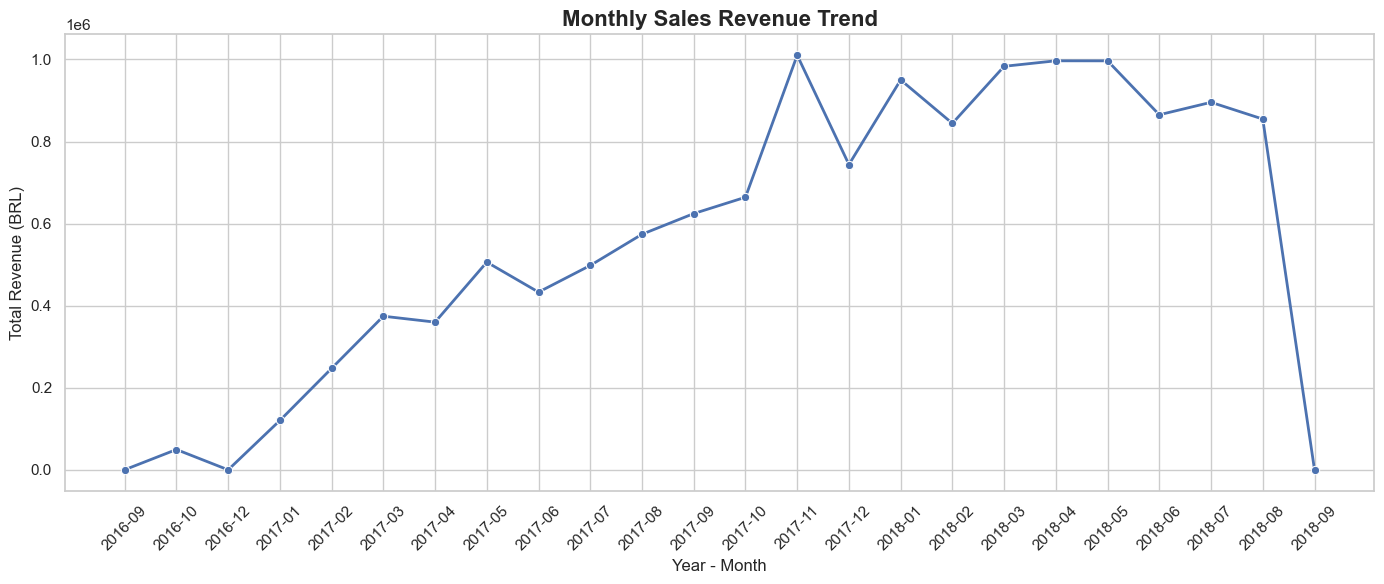

In [2]:
# استعلام اتجاه المبيعات
query_trend = """
SELECT 
    d.year_num, 
    d.month_num,
    d.month_name, 
    SUM(f.price) AS total_revenue
FROM dwh.fact_sales f
JOIN dwh.dim_date d ON f.purchase_date_sk = d.date_sk
GROUP BY d.year_num, d.month_num, d.month_name
ORDER BY d.year_num, d.month_num;
"""
df_trend = pd.read_sql(query_trend, engine)

# دمج السنة والشهر لتنسيق المحور السيني
df_trend['year_month'] = df_trend['year_num'].astype(str) + '-' + df_trend['month_num'].astype(str).str.zfill(2)

# رسم الخط البياني
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_trend, x='year_month', y='total_revenue', marker='o', color='b', linewidth=2)
plt.title('Monthly Sales Revenue Trend', fontsize=16, fontweight='bold')
plt.xlabel('Year - Month', fontsize=12)
plt.ylabel('Total Revenue (BRL)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\takam\AppData\Local\Temp\ipykernel_5256\3111375244.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cat, x='total_revenue', y='category_name', palette='viridis')


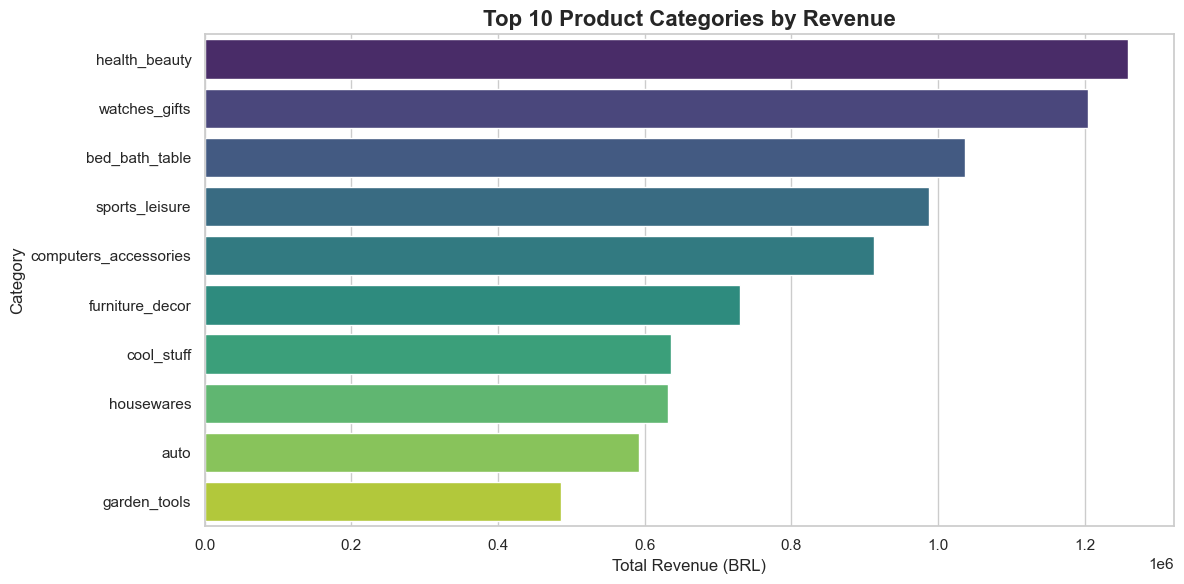

In [3]:
# استعلام أفضل التصنيفات المبيعة
query_cat = """
SELECT 
    p.product_category_name_english AS category_name, 
    SUM(f.price) AS total_revenue
FROM dwh.fact_sales f
JOIN dwh.dim_products p ON f.product_sk = p.product_sk
WHERE p.product_category_name_english IS NOT NULL
GROUP BY p.product_category_name_english
ORDER BY total_revenue DESC
LIMIT 10;
"""
df_cat = pd.read_sql(query_cat, engine)

# رسم الأعمدة
plt.figure(figsize=(12, 6))
sns.barplot(data=df_cat, x='total_revenue', y='category_name', palette='viridis')
plt.title('Top 10 Product Categories by Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue (BRL)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.show()